<a href="https://colab.research.google.com/github/abhaysenthilkumar369-web/cusat-internship/blob/main/ABHAY_S_Estimating_Pendulum_Parameters_from_Data_Using_Numerical_Curve_Fitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving pendulum_damped_data - pendulum_damped_data.csv to pendulum_damped_data - pendulum_damped_data (7).csv
Columns in CSV: Index(['time', 'theta'], dtype='object')
Estimated c, g, theta0, omega0 = [1.99999999e-01 9.79999999e+00 8.02730778e-09 9.99999988e-01]


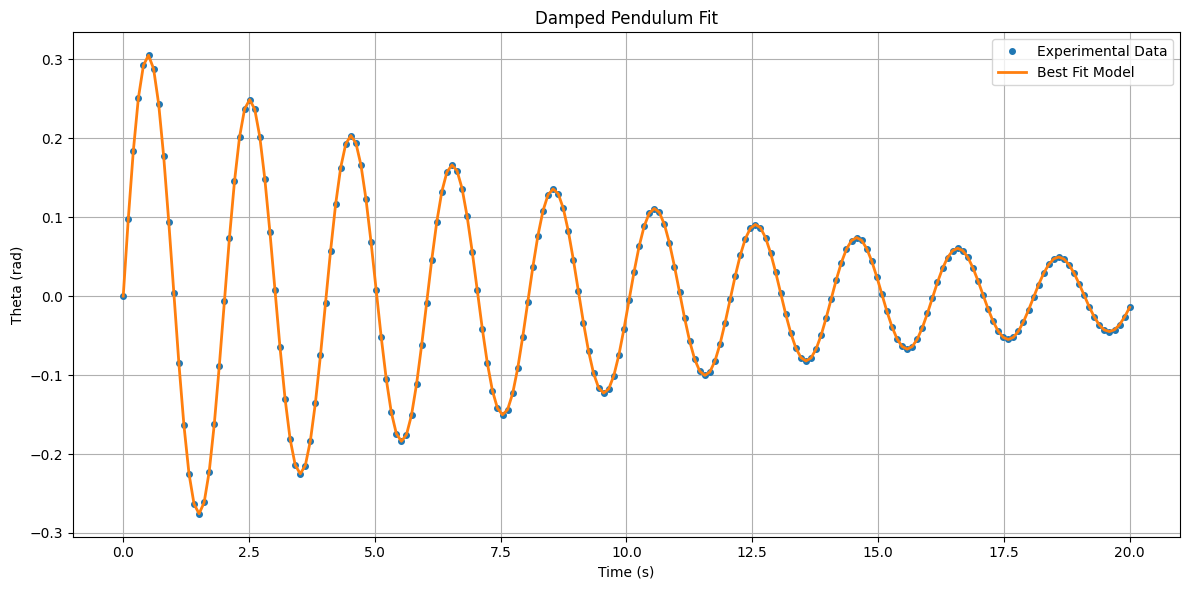

In [16]:
from google.colab import files
import io, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# Upload CSV
uploaded = files.upload()
filename = list(uploaded.keys())[0]
data = pd.read_csv(io.BytesIO(uploaded[filename]))

# Print column names to verify
print("Columns in CSV:", data.columns)

# Rename if needed (adjust based on actual names in your file)
data = data.rename(columns={'t': 'time', 'θ': 'theta', 'theta(rad)': 'theta'})

# Extract values
time, theta = data['time'].values, data['theta'].values

# Pendulum model
def pendulum(t, c, g, theta0, omega0):
    def ode(_, y):
        theta, omega = y
        return [omega, -c*omega - g*np.sin(theta)]
    sol = solve_ivp(ode, [t[0], t[-1]], [theta0, omega0], t_eval=t)
    return sol.y[0]

# Fit parameters
params, _ = curve_fit(lambda t,c,g,th0,w0: pendulum(t,c,g,th0,w0),
                      time, theta, p0=[0.1, 9.8, 0.1, 0])
print("Estimated c, g, theta0, omega0 =", params)

# Plot
plt.figure(figsize=(12,6))
plt.plot(time, theta, 'o', label="Experimental Data", markersize=4)
plt.plot(time, pendulum(time, *params), '-', label="Best Fit Model", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.title("Damped Pendulum Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
